<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>market movement prediciton - random forest(Jun Wang)</B></font></td></tr></table>

# Content
* generate daily sentiments and opinion disagreement
* merge stock market with sentiment data
* decision tree and random forest
* predict stock market one-day ahead movement with random forest

# generate daily sentiments and opinion disagreement

目前，我们计算了每条股评的情感打分。后续我们做股价涨跌预测是以天为单位的。因此，我们要为后续建模汇总每天的特征，例如每天的情感分数、意见分歧指数。

## get the daily sentiments scores

第一步：读取评论，这里只读取日期和情感打分，此后我们不再关注评论文本

In [1]:
import pandas as pd
comments = pd.read_csv("cleaned_300251_comments_sentiment.csv",
                      index_col=False, 
                      parse_dates = ["modified_date"],
                       usecols = ['modified_date','sentiment',"sentiment_dict_based","sentiment_MultinomialNB_clf","sentiment_sgd_clf"],
                       encoding = "gbk")
comments.head(5)

,modified_date,sentiment_dict_based,sentiment_MultinomialNB_clf,sentiment_sgd_clf,sentiment
0,2011-07-15,-1,-1,-1,-1
1,2011-07-15,-1,-1,-1,-1
2,2011-07-15,-1,-1,-1,-1
3,2011-07-15,-1,-1,-1,-1
4,2011-07-15,-1,-1,-1,-1


第二步：判断一条评论是正面评论还是负面评论，生成两列positive和negative

In [2]:
# 这里我们使用sentiment（即投票所得的情感分数）
# 后续大家也可以用其他情感标签做实验（'sentiment'，'sentiment_dict_based', 
# 'sentiment_MultinomialNB_clf','sentiment_sgd_clf'）的效果

sentiment_label = "sentiment"
comments["positive"] = comments[sentiment_label].apply(lambda x: 1 if x==1 else 0)
comments["negative"] = comments[sentiment_label].apply(lambda x: 1 if x==-1 else 0)
comments.tail()

,modified_date,sentiment_dict_based,sentiment_MultinomialNB_clf,sentiment_sgd_clf,sentiment,positive,negative
124329,2019-04-10,-1,1,1,1,1,0
124330,2019-04-10,1,-1,-1,-1,0,1
124331,2019-04-10,1,1,1,1,1,0
124332,2019-04-10,-1,-1,-1,-1,0,1
124333,2019-04-10,-1,-1,-1,-1,0,1


第三步：通过groupby日期进行分组,然后通过agg函数实现分组后情感分数列的求和，生成每天的情感分数：sentiment和ln_sentiment.特别提示，sentiment_day是每天的评论情感的汇总。
* $$ln\_sentiment=np.log\left(\frac {1+sentiment\_day["positive"]}{1+sentiment\_day["negative"]}\right)$$

In [3]:
import numpy as np

group_by_date = comments[["sentiment","positive","negative","modified_date"]].groupby(["modified_date"])

### groupby的对象

sentiment_day = group_by_date.agg(np.sum) 

# agg函数 - 聚合函数，对分组后数据进行聚合，默认情况对分组后其他列进行聚合

# 汇总每天的值

sentiment_day["ln_sentiment"] =np.log((1+sentiment_day["positive"])/((1+sentiment_day["negative"])))

In [4]:
sentiment_day.head(10)

,sentiment,positive,negative,ln_sentiment
modified_date,,,,
2011-07-15,-4,2,6,-0.847298
2011-07-16,-1,0,1,-0.693147
2011-07-18,0,1,1,0.000000
2011-07-19,-2,1,3,-0.693147
2011-07-20,-1,1,2,-0.405465
2011-07-21,-6,1,7,-1.386294
2011-07-22,-3,4,7,-0.470004
2011-07-23,3,4,1,0.916291
2011-07-24,-2,0,2,-1.098612


## get daily reviews counts and disaggreement

金融市场中交易的主要行为是由交易者对信息不同理解造成的，投资者不同的看法会引起交易量和价格的变化，为了测量投资者之间的**意见分歧度**，我们构建如下指数
$$ disaggreement = \vert1-\vert\frac{p-n}{p+n}\vert\vert$$
其中，n表示每天的负面情感评论数，p表示每天的正面情感评论数。
* Das, S., A. Martinez-Jerez, P. Tufano. 2005. e-Information. Financial Management 34(5) 103–137.
* Sanjiv R. Das, Mike Y. Chen, (2007) Yahoo! for Amazon: Sentiment Extraction from Small Talk on the Web. Management
Science 53(9):1375-1388.

In [5]:
# 每天股评总数
sentiment_day["comments_count"] = sentiment_day["positive"] + sentiment_day["negative"]

# 计算意见分歧指数
disaggreement = abs(1-abs((sentiment_day.positive-sentiment_day.negative)
                          /(sentiment_day.positive+sentiment_day.negative)))

sentiment_day["disaggreement"] = disaggreement
##生成意见分歧的列

In [6]:
sentiment_day.head(10)

,sentiment,positive,negative,ln_sentiment,comments_count,disaggreement
modified_date,,,,,,
2011-07-15,-4,2,6,-0.847298,8,0.500000
2011-07-16,-1,0,1,-0.693147,1,0.000000
2011-07-18,0,1,1,0.000000,2,1.000000
2011-07-19,-2,1,3,-0.693147,4,0.500000
2011-07-20,-1,1,2,-0.405465,3,0.666667
2011-07-21,-6,1,7,-1.386294,8,0.250000
2011-07-22,-3,4,7,-0.470004,11,0.727273
2011-07-23,3,4,1,0.916291,5,0.400000
2011-07-24,-2,0,2,-1.098612,2,0.000000


##  fill the missing value

由于某些天可能没有任何评论，那么对应的评论情绪就不存在，这不是特别合理，我们认为可以使用前一天的情绪数据填补。例如，我们查看sentiment_day[155:165]，我们发现2011-12-24没有任何评论，需要用近期的数据进行填充。

In [7]:
sentiment_day[155:165]

,sentiment,positive,negative,ln_sentiment,comments_count,disaggreement
modified_date,,,,,,
2011-12-19,-2,1,3,-0.693147,4,0.500000
2011-12-20,-2,1,3,-0.693147,4,0.500000
2011-12-21,1,2,1,0.405465,3,0.666667
2011-12-22,-4,0,4,-1.609438,4,0.000000
2011-12-23,0,1,1,0.000000,2,1.000000
2011-12-25,-1,0,1,-0.693147,1,0.000000
2011-12-26,-4,0,4,-1.609438,4,0.000000
2011-12-27,-2,5,7,-0.287682,12,0.833333
2011-12-28,-2,2,4,-0.510826,6,0.666667


In [8]:
# D表示每天，以天为单位重采样，如果有缺失的天，则会引入缺失值。

# 我们使用函数ffill()将前一天的数值填充到缺失值上。


sentiment_day = sentiment_day.resample("D").ffill()

# https://blog.csdn.net/wangshuang1631/article/details/52314944

In [9]:
sentiment_day[155:165]

,sentiment,positive,negative,ln_sentiment,comments_count,disaggreement
modified_date,,,,,,
2011-12-17,-2,1,3,-0.693147,4,0.500000
2011-12-18,-2,1,3,-0.693147,4,0.500000
2011-12-19,-2,1,3,-0.693147,4,0.500000
2011-12-20,-2,1,3,-0.693147,4,0.500000
2011-12-21,1,2,1,0.405465,3,0.666667
2011-12-22,-4,0,4,-1.609438,4,0.000000
2011-12-23,0,1,1,0.000000,2,1.000000
2011-12-24,0,1,1,0.000000,2,1.000000
2011-12-25,-1,0,1,-0.693147,1,0.000000


## generate cumulative lagged scores

### rolling  and shift function
我们首先学习一下[rolling](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.shift.html)函数（**滚动**），用来汇总历史数据，例如移动平均值，移动求和等。参考下面的[示意图](https://baijiahao.baidu.com/s?id=1622798772654712959&wfr=spider&for=pc)。

<img src="../img/rolling.png" align='left' height="400" width="600"/>

In [10]:
## rolling 的 例子

df = pd.DataFrame({'A': [10, 20, 15, 30, 45],
                    'B': [13, 23, 18, 33, 48],
                    'C': [17, 27, 22, 37, 52]})

df["moving_average_A"] = df.A.rolling(window = 2).mean() # 向后、均值、滚动

df

,A,B,C,moving_average_A
0,10,13,17,NaN
1,20,23,27,15.0
2,15,18,22,17.5
3,30,33,37,22.5
4,45,48,52,37.5


In [11]:
## shift的例子，把数据向前或向后移动生成新的列

#df["shift_1_B"] = df.B.shift(1) # 向下移动（滞后）

df["shift_1_A"] = df.A.shift(-1) # 向上移动（前置）

df

,A,B,C,moving_average_A,shift_1_A
0,10,13,17,NaN,20.0
1,20,23,27,15.0,15.0
2,15,18,22,17.5,30.0
3,30,33,37,22.5,45.0
4,45,48,52,37.5,NaN


### generate cumulative lagged reviews counts

生成滞后（过去）1-6天的正面评论个数（### 前几天的情感，对今天的影响）

In [12]:
for i in range(1,7):
    c = "positive_shift_{}".format(i)
    sentiment_day[c] = sentiment_day.positive.shift(i)

生成滞后（过去）1-6天的负面评论个数（### 前几天的情感，对今天的影响）

In [13]:
for i in range(1,7):
    c = "negative_shift_{}".format(i)
    sentiment_day[c] = sentiment_day.negative.shift(i)

生成累积1-6天的正面评论个数与负面评论个数

In [14]:
# 累积1-6天的正面评论个数（包含当天共2-7天）

for i in range(1,7):
    c = "commulative_positive_lagged_{}".format(i)
    sentiment_day[c] = sentiment_day.positive.rolling(window = i+1).sum() # 可以求和 也可以求平均
    
# 累积1-6天的负面评论个数（包含当天共2-7天）

for i in range(1,7):
    c = "commulative_negative_lagged_{}".format(i)
    sentiment_day[c] = sentiment_day.negative.rolling(window = i+1).sum()

### generate cumulative lagged sentiments

计算lagged_days = 1:6天的情感 = 累积正面情感数 - 累积负面情感数

In [15]:
for i in range(1,7):
    c = 'commulative_sentiment_score_lagged_{}'.format(i)
    p_c = 'commulative_positive_lagged_{}'.format(i)
    n_c = 'commulative_negative_lagged_{}'.format(i)
    sentiment_day[c] = sentiment_day[p_c] - sentiment_day[n_c] # 累计情感的差异计算（情感变动值）

计算lagged_days = 1:6天的情感分数（ln） 
$$ ln.sentiment = np.log(\frac {1+p} {1+n})$$  
其中，n表示每天的负面情感评论数，p表示每天的正面情感评论数。

In [16]:
for i in range(1,7):
    c = 'ln_commulative_sentiment_lagged_{}'.format(i)
    p_c = 'commulative_positive_lagged_{}'.format(i)
    n_c = 'commulative_negative_lagged_{}'.format(i)
    sentiment_day[c] = np.log((1+sentiment_day[p_c])/((1+sentiment_day[n_c])))

### generate cumulative lagged disagreement
$$ disaggreement = \vert1-\vert\frac{p-n}{p+n}\vert\vert$$

In [17]:
for i in range(1,7):
    c = 'commulative_disaggreement_lagged_{}'.format(i)
    p_c = 'commulative_positive_lagged_{}'.format(i)
    n_c = 'commulative_negative_lagged_{}'.format(i)
    disaggreement = abs(1-abs((sentiment_day[p_c]-sentiment_day[n_c])/(sentiment_day[p_c]+sentiment_day[n_c])))
    sentiment_day[c] = disaggreement

### generate the changes of sentiment and disagreement

（**计算情感变动**）有时情感变动量的预测价值会较高。因此，在特征工程中，我们尝试引入情感与意见分歧指数变动量。

In [18]:
cols = ['sentiment', 'positive', 'negative', 'ln_sentiment', 'comments_count',
       'disaggreement', 'commulative_positive_lagged_1',
       'commulative_positive_lagged_2', 'commulative_positive_lagged_3',
       'commulative_positive_lagged_4', 'commulative_positive_lagged_5',
       'commulative_positive_lagged_6', 'commulative_negative_lagged_1',
       'commulative_negative_lagged_2', 'commulative_negative_lagged_3',
       'commulative_negative_lagged_4', 'commulative_negative_lagged_5',
       'commulative_negative_lagged_6', 'commulative_sentiment_score_lagged_1',
       'commulative_sentiment_score_lagged_2',
       'commulative_sentiment_score_lagged_3',
       'commulative_sentiment_score_lagged_4',
       'commulative_sentiment_score_lagged_5',
       'commulative_sentiment_score_lagged_6',
       'ln_commulative_sentiment_lagged_1',
       'ln_commulative_sentiment_lagged_2',
       'ln_commulative_sentiment_lagged_3',
       'ln_commulative_sentiment_lagged_4',
       'ln_commulative_sentiment_lagged_5',
       'ln_commulative_sentiment_lagged_6',
       'commulative_disaggreement_lagged_1',
       'commulative_disaggreement_lagged_2',
       'commulative_disaggreement_lagged_3',
       'commulative_disaggreement_lagged_4',
       'commulative_disaggreement_lagged_5',
       'commulative_disaggreement_lagged_6']

for c in cols:
    delta_col = "delta_"+c # 命名规则
    sentiment_day[delta_col] = sentiment_day[c] - sentiment_day[c].shift(1) # 计算情感的变动情况

## save data

In [19]:
print(sentiment_day.columns)
sentiment_day.to_csv("preprocessed_300251_comments_sentiment_day.csv")

Index(['sentiment', 'positive', 'negative', 'ln_sentiment', 'comments_count',
       'disaggreement', 'positive_shift_1', 'positive_shift_2',
       'positive_shift_3', 'positive_shift_4', 'positive_shift_5',
       'positive_shift_6', 'negative_shift_1', 'negative_shift_2',
       'negative_shift_3', 'negative_shift_4', 'negative_shift_5',
       'negative_shift_6', 'commulative_positive_lagged_1',
       'commulative_positive_lagged_2', 'commulative_positive_lagged_3',
       'commulative_positive_lagged_4', 'commulative_positive_lagged_5',
       'commulative_positive_lagged_6', 'commulative_negative_lagged_1',
       'commulative_negative_lagged_2', 'commulative_negative_lagged_3',
       'commulative_negative_lagged_4', 'commulative_negative_lagged_5',
       'commulative_negative_lagged_6', 'commulative_sentiment_score_lagged_1',
       'commulative_sentiment_score_lagged_2',
       'commulative_sentiment_score_lagged_3',
       'commulative_sentiment_score_lagged_4',
       'com

思考：<font color=red face=雅黑>对比一下三个情感累积变量的分布："positive","commulative_positive_lagged_1","commulative_positive_lagged_6"，通过图示观察他们的分布，并通过[describe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)函数对比三者的特征</font>

array([<AxesSubplot:xlabel='modified_date'>,
       <AxesSubplot:xlabel='modified_date'>,
       <AxesSubplot:xlabel='modified_date'>,
       <AxesSubplot:xlabel='modified_date'>], dtype=object)

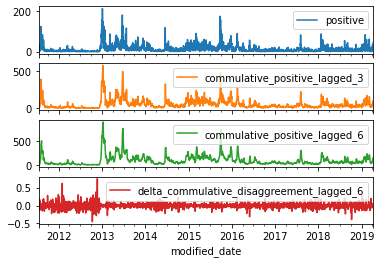

In [20]:
columns=["positive","commulative_positive_lagged_3","commulative_positive_lagged_6","delta_commulative_disaggreement_lagged_6"]

sentiment_day[columns].plot(subplots=True) # dataframe - 列 - 可视化

In [21]:
sentiment_day[columns].describe()

,positive,commulative_positive_lagged_3,commulative_positive_lagged_6,delta_commulative_disaggreement_lagged_6
count,2827.000000,2824.000000,2821.000000,2820.000000
mean,14.033958,56.110482,98.230415,0.000034
std,18.545050,63.757687,105.043480,0.065735
min,0.000000,0.000000,0.000000,-0.454545
25%,3.000000,17.750000,33.000000,-0.029714
50%,8.000000,35.000000,63.000000,-0.000505
75%,18.000000,72.000000,132.000000,0.028636
max,214.000000,576.000000,897.000000,0.750000


# merge stock market with sentiment data

除了股吧情感，我们还需要引入百度指数和市场数据。

* 百度指数代表人们对企业的注意力；
* 通过市场数据我们可以计算收益率和涨跌信息。

重点：学习合并不同来源的数据。

## Introduce Baidu index
大家是在买股票还是卖股票时更需要搜索网络数据。

<img src="../img/search.png" align='left' height="400" width="600"/>

In [22]:
# 读取百度指数（我们之前提前下载了百度“光线传媒”搜索指数）

import pandas as pd
baidu_index = pd.read_excel("baidu_guangxian.xlsx",index_col="Date",parse_dates = ["Date"])

In [23]:
baidu_index.head()

,baidu_index
Date,
2011-01-01,596
2011-01-02,628
2011-01-03,556
2011-01-04,539
2011-01-05,573


In [24]:
# 生成滞后1天的百度指数
baidu_index["baidu_index_lag1"] = baidu_index.baidu_index.shift(1)

In [25]:
# 累积1-6天的baidu_index（包含当天共2-7天）
for i in range(1,7):
    c = "commulative_baidu_lagged_{}".format(i)
    baidu_index[c] = baidu_index.baidu_index.rolling(window = i+1).sum()

In [26]:
baidu_index.columns

Index(['baidu_index', 'baidu_index_lag1', 'commulative_baidu_lagged_1',
       'commulative_baidu_lagged_2', 'commulative_baidu_lagged_3',
       'commulative_baidu_lagged_4', 'commulative_baidu_lagged_5',
       'commulative_baidu_lagged_6'],
      dtype='object')

In [27]:
cols = ['commulative_baidu_lagged_1', 'commulative_baidu_lagged_2',
       'commulative_baidu_lagged_3', 'commulative_baidu_lagged_4',
       'commulative_baidu_lagged_5', 'commulative_baidu_lagged_6']
for c in cols:
    delta_col = "baidu_delta_"+c
    baidu_index[delta_col] = baidu_index[c].pct_change() 
    
## 生成指数的变动

In [28]:
# 生成百度指数变动百分比

baidu_index["pct_change_baidu_index_lag1"] = baidu_index.baidu_index_lag1.pct_change()

## get volatility, return, closing price changes, and market movement

首先，读取上证综指(trade_sh)和光线传媒(trade)股价市场信息

In [29]:
trade_sh = pd.read_csv("000001_trade.csv",index_col= "Date",parse_dates = ["Date"])
trade = pd.read_csv("300251_trade.csv",index_col = "Date",parse_dates = ["Date"])
trade.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2011-08-03,3.11688,2.91417,2.95038,3.08025,464007031.0,2.093177
2011-08-04,3.20388,3.00949,3.19098,3.02489,220479900.0,2.055557
2011-08-05,3.17516,2.87379,2.97161,3.14019,230343337.0,2.133909
2011-08-08,3.18598,2.92666,3.14269,3.08400,178499569.0,2.095725
2011-08-09,3.39244,3.03030,3.03863,3.31335,203363472.0,2.251579


In [30]:
# 获得滞后一天的收盘价
trade["close_lag1"] = trade['Close'].shift(1)
trade_sh["close_lag1"] = trade_sh['Close'].shift(1)

然后，我们计算波动率和波动率的滞后1期的数值。怎么测量波动率呢？
用当天的最高股价和最低股价之差除以开盘价和收盘价的平均值来衡量日内**波动率**。

$$volatility = \frac {trade["High"]-trade["Low"]}{(trade["Open"]+trade["Close"])/2}$$


参考文献：Das, S. R., & Chen, M. Y. (2007). Yahoo! for Amazon: Sentiment Extraction from Small Talk on the Web. Management Science, 53(9), 1375-1388.

In [31]:
trade["volatility"] = (trade["High"]-trade["Low"])/(trade["Open"]+trade["Close"])/2
trade_sh["volatility"] = (trade_sh["High"]-trade_sh["Low"])/(trade_sh["Open"]+trade_sh["Close"])/2

In [32]:
trade["volatility_lag1"] = trade['volatility'].shift(1)
trade_sh["volatility_lag1"] = trade_sh['volatility'].shift(1)

计算波动率变动

In [33]:
trade["delta_volatility"] = trade["volatility"] - trade["volatility_lag1"]
trade_sh["delta_volatility"] = trade_sh["volatility"] - trade_sh["volatility_lag1"]

计算收益率：收盘价的变动百分比

In [34]:
trade['return'] = trade.Close.pct_change()
trade_sh['return'] = trade_sh.Close.pct_change()

In [35]:
# 计算上一天收盘价的收益率
trade["return_lag1"] = trade['return'].shift(1)
trade_sh["return_lag1"] = trade_sh['return'].shift(1)

生成收盘价的绝对变动数量

In [36]:
trade["delta_close"] = trade["Close"] - trade['Close'].shift(1)
trade_sh["delta_close"] = trade_sh["Close"] - trade_sh['Close'].shift(1)

计算up_down，如果当天收盘价大于前一天收盘价，我们标记为涨=1，否则跌=0。

* 参考文献：Weng, B., Ahmed, M. A., & Megahed, F. M. (2017). Stock market one-day ahead movement prediction using disparate data sources. Expert Systems With Applications, 79(79), 153-163.

In [37]:
trade["up_down"] = (trade['delta_close']>0).astype("int") 

## 新加一列 up 或者 down ## true 和 false 转化为 int 既 1 和 0

trade_sh["up_down"] = (trade_sh['delta_close']>0).astype("int")
trade.head()

,High,Low,Open,Close,Volume,Adj Close,close_lag1,volatility,volatility_lag1,delta_volatility,return,return_lag1,delta_close,up_down
Date,,,,,,,,,,,,,,
2011-08-03,3.11688,2.91417,2.95038,3.08025,464007031.0,2.093177,NaN,0.016807,NaN,NaN,NaN,NaN,NaN,0
2011-08-04,3.20388,3.00949,3.19098,3.02489,220479900.0,2.055557,3.08025,0.015637,0.016807,-0.001170,-0.017973,NaN,-0.05536,0
2011-08-05,3.17516,2.87379,2.97161,3.14019,230343337.0,2.133909,3.02489,0.024655,0.015637,0.009018,0.038117,-0.017973,0.11530,1
2011-08-08,3.18598,2.92666,3.14269,3.08400,178499569.0,2.095725,3.14019,0.020823,0.024655,-0.003831,-0.017894,0.038117,-0.05619,0
2011-08-09,3.39244,3.03030,3.03863,3.31335,203363472.0,2.251579,3.08400,0.028506,0.020823,0.007683,0.074368,-0.017894,0.22935,1


我们也尝试预测后续几天的收盘价波动，下面生成接下来5天的股价涨跌

In [38]:
for i in range(1,6):
    trade["up_down-{}".format(i)] = trade.up_down.shift(-i) 
    
# 注意：这里是负号，向前、向上移动（用于预测，也就是预测的标签）

## merge stock market and sentiment data

In [39]:
# 首先读取上节课处理后的数据，即每天的情感数据集
sentiment_daily = pd.read_csv("preprocessed_300251_comments_sentiment_day.csv",
                      index_col="modified_date", 
                      parse_dates = ["modified_date"],
                       encoding = "gbk")
sentiment_daily.head()

,sentiment,positive,negative,ln_sentiment,comments_count,disaggreement,positive_shift_1,positive_shift_2,positive_shift_3,positive_shift_4,...,delta_ln_commulative_sentiment_lagged_3,delta_ln_commulative_sentiment_lagged_4,delta_ln_commulative_sentiment_lagged_5,delta_ln_commulative_sentiment_lagged_6,delta_commulative_disaggreement_lagged_1,delta_commulative_disaggreement_lagged_2,delta_commulative_disaggreement_lagged_3,delta_commulative_disaggreement_lagged_4,delta_commulative_disaggreement_lagged_5,delta_commulative_disaggreement_lagged_6
modified_date,,,,,,,,,,,,,,,,,,,,,
2011-07-15,-4,2,6,-0.847298,8,0.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-16,-1,0,1,-0.693147,1,0.0,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-17,-1,0,1,-0.693147,1,0.0,0.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.444444,NaN,NaN,NaN,NaN,NaN
2011-07-18,0,1,1,0.000000,2,1.0,0.0,0.0,2.0,NaN,...,NaN,NaN,NaN,NaN,0.666667,0.100000,NaN,NaN,NaN,NaN
2011-07-19,-2,1,3,-0.693147,4,0.5,1.0,0.0,0.0,2.0,...,0.068993,NaN,NaN,NaN,0.000000,0.071429,0.0,NaN,NaN,NaN


我们使用[merge](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)函数合并数据集。下面我们合并trade和trade_sh，由于这两个数据集有很多相同的变量，我们使用后缀想("_GX","_SH")，其中前者表示光纤传媒，后缀表示上证指数。

how : {‘left’, ‘right’, ‘outer’, ‘inner’}, default ‘inner’
* left: use only keys from left frame, similar to a SQL left outer join; preserve key order.
* right: use only keys from right frame, similar to a SQL right outer join; preserve key order.

In [40]:
trade_merged = pd.merge(left=trade, ##先合并两个交易数据
                        right=trade_sh,
                        left_index = True, ##按照索引，进行合并
                        right_index = True,
                        suffixes = ("_GX","_SH"), # 前面的是光线传媒，后面的是上证综指
                        how="left") ## 只保留left相同的数据，对齐数据（例如，日期）
#trade_merged.columns
trade_merged.head()

,High_GX,Low_GX,Open_GX,Close_GX,Volume_GX,Adj Close_GX,close_lag1_GX,volatility_GX,volatility_lag1_GX,delta_volatility_GX,...,Volume_SH,Adj Close_SH,close_lag1_SH,volatility_SH,volatility_lag1_SH,delta_volatility_SH,return_SH,return_lag1_SH,delta_close_SH,up_down_SH
Date,,,,,,,,,,,,,,,,,,,,,
2011-08-03,3.11688,2.91417,2.95038,3.08025,464007031.0,2.093177,NaN,0.016807,NaN,NaN,...,64000,2678.485107,2679.259033,0.003157,0.003603,-0.000446,-0.000289,-0.009070,-0.773926,0
2011-08-04,3.20388,3.00949,3.19098,3.02489,220479900.0,2.055557,3.08025,0.015637,0.016807,-0.001170,...,58800,2684.039062,2678.485107,0.002169,0.003157,-0.000988,0.002074,-0.000289,5.553955,1
2011-08-05,3.17516,2.87379,2.97161,3.14019,230343337.0,2.133909,3.02489,0.024655,0.015637,0.009018,...,78600,2626.423096,2684.039062,0.003759,0.002169,0.001590,-0.021466,0.002074,-57.615967,0
2011-08-08,3.18598,2.92666,3.14269,3.08400,178499569.0,2.095725,3.14019,0.020823,0.024655,-0.003831,...,110400,2526.815918,2626.423096,0.011341,0.003759,0.007582,-0.037925,-0.021466,-99.607178,0
2011-08-09,3.39244,3.03030,3.03863,3.31335,203363472.0,2.251579,3.08400,0.028506,0.020823,0.007683,...,103800,2526.070068,2526.815918,0.009985,0.011341,-0.001356,-0.000295,-0.037925,-0.745850,0


合并sentiment_daily和trade_merged

In [41]:
sentiment_trade_merged = pd.merge(left=trade_merged,
                        right=sentiment_daily,
                        left_index = True,
                        right_index = True, # left 和 right 相同的列进行保留，以left表为标准（行）
                        how="left")

将百度指数合并在一起

In [42]:
sentiment_trade_baidu_merged = pd.merge(left=sentiment_trade_merged,
                        right=baidu_index,
                        left_index = True,
                        right_index = True,
                        how="left")

In [43]:
print(sentiment_trade_baidu_merged.shape)
for c in sentiment_trade_baidu_merged.columns:
    print(c)

(1906, 132)
High_GX
Low_GX
Open_GX
Close_GX
Volume_GX
Adj Close_GX
close_lag1_GX
volatility_GX
volatility_lag1_GX
delta_volatility_GX
return_GX
return_lag1_GX
delta_close_GX
up_down_GX
up_down-1
up_down-2
up_down-3
up_down-4
up_down-5
High_SH
Low_SH
Open_SH
Close_SH
Volume_SH
Adj Close_SH
close_lag1_SH
volatility_SH
volatility_lag1_SH
delta_volatility_SH
return_SH
return_lag1_SH
delta_close_SH
up_down_SH
sentiment
positive
negative
ln_sentiment
comments_count
disaggreement
positive_shift_1
positive_shift_2
positive_shift_3
positive_shift_4
positive_shift_5
positive_shift_6
negative_shift_1
negative_shift_2
negative_shift_3
negative_shift_4
negative_shift_5
negative_shift_6
commulative_positive_lagged_1
commulative_positive_lagged_2
commulative_positive_lagged_3
commulative_positive_lagged_4
commulative_positive_lagged_5
commulative_positive_lagged_6
commulative_negative_lagged_1
commulative_negative_lagged_2
commulative_negative_lagged_3
commulative_negative_lagged_4
commulative_negati

In [44]:
sentiment_trade_baidu_merged.to_csv("preprocessed_300251_comments_sentiment_trade_baidu.csv")

思考：<font color=red face=雅黑>可以自己生成一些特征，鼓励大家提取合适的特征，有助于提升市场涨跌预测的效果，根据您的经验或文献阅读，结合现有的数据，请生成一项新的特征，并尝试编程实现</font>

参考文献：Weng, B., Ahmed, M. A., & Megahed, F. M. (2017). Stock market one-day ahead movement prediction using disparate data sources. Expert Systems with Applications, 79, 153-163.

# decision tree and random forest

为了应用上节课生成的多项特征预测股价的涨跌，我们拟使用决策树和随机森林模型。决策树会生成类似if-then的规则集合，主要优点是：模型的可解释性高，分类速度快。随机森林有其独特的优点：能够处理很高维度的数据，并且不用做特征选择，模型泛化能力强。

参考资料：
* 李航：统计学习方法，2012，北京.清华大学出版社.
* 周志华 著.机器学习,2016，北京:清华大学出版社.
* Aurélien Géron：Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow. 2019,O’Reilly Media, Inc.

## decision tree

决策树由节点和边组成，节点有两种类型，内部节点（例如1、2、3、5、6）和叶子节点（例如4）。**内部节点**表示一个特征或属性，**叶子节点**表示一个类。我们用周志华（2016）的西瓜分类的示意图来展示决策树的形状**（PPT内容）**：

<img src="../img/tree.png" align='left' height="400" width="450"/>
<img src="../img/1654488555265.jpg" align='right' height="400" width="450"/>

决策树是对于给定特征空间上的一个划分，树上每一条从根节点到叶节点的路径将特征空间划分成互不相交的一个区域。下图示例：决策树对应于条件概率分布。

<img src="../img/decision_tree.png" align='left' height="600" width="700"/>

构建决策树很重要的一步是要**选取分支特征**。

下面用一个贷款数据为例解释如何选择分类特征(李航 2012)。表中有15个训练样本，每个样本有4个特征：年龄（青年、中年、老年）、是否工作、是否有房子、信贷情况（一般、好、非常好）。训练样本类别标签有两类，分别是是否提供贷款。

<img src="../img/loan.png" align='left' height="700" width="800"/>

上面的特征有年龄、是否有工作、是否有自己的房子、信贷情况，例如我们可以选择年龄来划分、也可以选择是否有工作来划分，如下图所示。

这样的决策树可以有多种，但是哪一种是最好的呢? 一个好的决策树，**分类完成后在叶节点中的样本的类别相比全部训练样本应该更加纯**。比如在上边例子中，所有样本中类别为“是和否”的分布占比为60%和40%，如果我们用“是否有工作”来进行分类，那分类完成后，有工作的样本类别“是和否”分布占比为100%，0%，没工作的样本类别“是和否”分布占比为40%，60%。可以看出，用工作来进行样本的分类比原样本是有提升的。

<img src="../img/feature.png" align='left' height="300" width="400"/>

直观上，如果一个特征具有更好的分类能力，或者说，按照这一特征将训练数据集分割成子集，使得各个子集在当前条件下有最好的分类，那么就更应该选择这个特征。**信息增益**就能够很好地表示这一直观的准则。

什么是信息增益呢？在划分数据集之前与之后**信息发生的变化成为信息增益**，知道如何计算信息增益，我们就可以计算每个特征值划分数据集获得的信息增益，获得信息增益最高的特征就是最好的选择。下面我介绍相关概念：熵。**可以把熵理解为：如果你从集合中随机抽取一个元素并猜测其结果，那么其结果的不确定性是多少？**

>数学上用熵来表示随机变量的混乱度，设有一个随机变量$X$，其概率分布为$P(X = x_i) = p_i$
则其熵可以定义为$H(X) = -\sum_{i=1}^kp_ilog(p_i)$
由于上式和X无关，只和概率分布相关，因此可以修改为$$H(p) = -\sum_{i=1}^kp_ilog(p_i)$$

为什么使用负对数和概率$p_i$相乘呢**（PPT内容）**
$$H(p) = -\sum_{i=1}^kp_ilog(p_i)$$

$p_i$相当于权重，表示大概率的结果对一个集体和熵值贡献比小概率的结果大。

$log(p_i)^{-1}=-log(p_i)$,这样$p_i$越大，$-log(p_i)$就越小。

/var/folders/kb/tv69ch3n1936k84ysf8skrph0000gn/T/ipykernel_9613/2724593648.py:4: RuntimeWarning: divide by zero encountered in log2
  y = -np.log2(x)


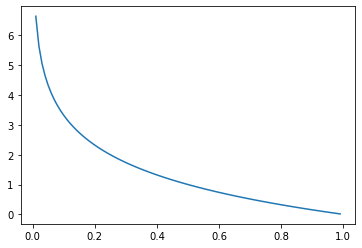

In [45]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(0,1,0.01)
y = -np.log2(x)
plt.plot(x,y)

**熵越大时，则表明随机变量的混乱度越高**，下边举例说明。
假设随机变量只有两个取值$x_1$和$x_2$，则其概率分布的取值为$p$和$1-p$，此时的熵为$$H(p) = -plog_2p-(1-p)log_2(1-p)$$

这时熵H(p)随p变化的图像如下图所示，可以看到当p=0.5时，也就是随机变量完全均匀时，熵取最大值。

<img src="../img/entropy.png" align='left' height="450" width="600"/>

设有随机变量$(X,Y)$,其联合概率分布为：$$P(X = x_i, Y = y_j) = p_{ij}, i = 1,2,...,n; j = 1,2,...,m$$

**条件熵$H(Y|X)$表示在已知随机变量$X$的条件下随机变量Y的不确定性**，条件熵的表示如下：$$H(Y|X) = \sum_{i=1}^n p_iH(Y|X = x_i) $$
这里$p_i = P(X = x_i), i = 1,2,...,n$

**当熵和条件熵的概率有数据估计得到时，所对应的熵称为经验熵，对应的条件熵称为经验条件熵**。什么叫由数据估计？比如有10个数据，一共有两个类别，A类和B类。其中有7个数据属于A类，则该A类的概率可以估计为十分之七。其中有3个数据属于B类，则该B类的概率即为十分之三。浅显的解释就是，这概率是我们根据数据数出来的。

>信息增益表示得知特征$X$的信息而使得$Y$的信息的不确定性减少的程度。下面定义特征$A$对训练数据集$D$的信息增益$g(D,A)$,定义**集合D的经验熵为$H(D)$与特征A给定条件下D的经验条件熵为$H(D|A)$之差**，$$g(D,A) = H(D) - H(D|A)$$

我们定义贷款申请样本数据表中的数据为训练数据集D，则训练数据集D的经验熵为$H(D)$，$|D|$表示其样本容量，及样本个数。设有$K$个类$C_k$，$k = 1,2,3,...,K$，$|Ck|$为属于类$C_k$的样本个数，这经验熵公式可以写为：$$H(D) = -\sum_{k=1}^K \frac {|C_k|}{|D|}log_2\frac {|C_k|}{|D|}$$
在我们的样本$D$中有6个不贷款，9个贷款，那么经验熵$$H(D) = -\frac {9}{15} log_2\frac {9}{15} - \frac {6}{15} log_2\frac {6}{15} = 0.975$$

特征$A$将$D$分为$n$个子集，每个子集的样本个数是$D_i$,那么特征$A$对数据集$D$的经验条件熵$H(D|A)$:$$H(D|A) = -\sum_{i = 1}^n\frac {|D_i|}{|D|}\sum_{k=1}^K \frac {|D_{ik}|}{|D_i|}log_2\frac {|D_{ik}|}{|D_i|}$$
计算了$H(D)$和$H(D|A)$，我们就可以得到$g(D,A) = H(D) - H(D|A)$

如果我们用$A_1,A_2,A_3,A_4$分别表示年龄、工作、有自己房子、信贷情况4个特征。这里我们用$A_1$（年龄）来做例子，计算用特征年龄后的信息增益，用年龄可以将人群分为青年、中年、老年，每个子人群($D_i$)都是5个，$$g(D,A_1) = H(D) - [\frac {5}{15}H(D_1) + \frac {5}{15}H(D_2) + \frac {5}{15}H(D_3)] \\ = 0.975 - [\frac {5}{15} (-\frac {2}{5}log_2\frac {2}{5} - \frac {3}{5}log_2\frac {3}{5})] + [\frac {5}{15} (-\frac {3}{5}log_2\frac {3}{5} - \frac {2}{5}log_2\frac {2}{5})] + [\frac {5}{15} (-\frac {4}{5}log_\frac {4}{5} - \frac {1}{5}log_2\frac {1}{5})] \\ = 0.975- 0.888 = 0.083$$ 

按照相似的逻辑，我们可以计算出$g(D,A_2) = 0.324, g(D,A_3) = 0.420$



思考题：<font color=red face=雅黑>在本节课的信贷决策树构建过程中,我们已经计算出$A_1，A_2，A_3$特征对样本的信息增益，请您接下来**计算特征$A_4$（信贷情况）对样本的信息增益**，并从$A_1,A_2,A_3,A_4$选取信息增益最大的特征作为最优特征来分支？</font>

**ID3算法的核心是在决策树的各个节点上利用信息增益来选取特征，递归构建决策树**。

具体方法为：从根节点开始，对其包含的所有样本的所有特征计算信息增益，**选取增益最大的特征作为节点特征（这样我们可以构建较浅的树）**，建立子节点，再对子节点递归进行以上操作，**直到**没有再能够分类的特征，或分类后信息增益小于某个阈值,或者数据集中所有实例都具有相同的类别标签，停止递归构建树。

这里要强调一下**叶子节点的分类输出**：叶子节点样本中数目最多的样本对应的类$C_k$作为该节点的类标签。

上面的计算说明，**有无房子这个特征的信息增益是最大的**。因此，首先利用这个特征来构建树的根节点，将样本分为两个子集$D_1（A_3取值为“是”）,D_2（A_3取值为“否”）$
* $D_1$中所有样本类别均为是，因此不必再对$D_1$继续分类。
* 接着针对$D_2$需要从$A_1、A_2、A_4$中选择特征，我们发现$g(D,A_4)$最大，因此我们选择**是否有工作**作为最优的分支特征。分类完成后，有工作的样本类别都标记为"是"，没工作的样本类别都标记为"否"。样本不必再分类了。

<img src="../img/id3.png" align='left' height="300" width="300"/>

回归树：预测连续目标的任务称为回归任务，回归树叶子节点的输出是训练集中该节点中，**实例目标特征值的平均值**。因此，我们可以使用**方差**作为对纯度的度量。

即：采用的原则是最小均方差，对于任意划分特征A，对应的任意划分点s两边划分成的数据集D1和D2，求出使D1和D2各自集合的均方差最小，同时D1和D2的均方差之和最小所对应的特征和特征值划分点。

**预测是根据叶子结点的均值**，因此随机森林预测是所有树的预测值的平均值。

## random forest

集成学习（ensemble learning）通过构建并结合多个学习器来完成学习任务，有时也被称为多分类器系统。有两种创建组合的标准方法：提升法（boosting）和袋装法（bagging）。这里我们介绍bagging（袋装法）。Bagging（bootstrap aggregating）采用的是**随机有放回的选择训练数据**构造分类器，最后组合。**（PPT）** 如下图所示：

<img src="../img/bagging.png" align='left' height="500" width="600"/>

采用有放回的抽样的主要目的是，使得资助采样样本每次都不同，因此训练出来的模型也是不同的。

决策树算法特别适合袋装法，因为决策树对数据集的改变非常敏感，数据集的微小改变可能导致算法选择不同的特征来生成节点。

随机森林是bagging中的一种方法。随机森林构造很多颗决策树，形成一个森林，然后用这些决策树共同决策输出类别是什么。在随机森林算法的过程中，有**两个随机的操作**：
* 特征选取随机选择：每棵决策树所需的特征是从整体的特征集中随机选取的。这也成为子空间采样。
* 输入数据随机选择：从全部训练样本（样本数为N）中选取一个可能有重复的大小同样为N的数据集进行训练（即bootstrap取样）。 


袋装法、**子空间采样**和决策树的结合，形成了随机森林。

<img src="../img/rf.jfif" align='left' height="400" width="500"/>

随机森林算法具体实现过程：
* A: 随机且有放回地从训练集中的抽取N个训练样本。
* B: 选取输入的训练数据后，构建决策树（方法：每一个分裂节点从整体的特征集M中选取m个特征构建，一般情况下m远小于M，通常是log_2(M)或者sqrt(M)），从这m个属性中根据某种策略（如信息增益）确定分支属性。
* C: 重复B步骤，直到不能分裂或达到我们设定的阈值（如叶子结点树或的树的深度），此时建立了一个决策树

**重复上面的A,B,C步骤，直到达到预定数目的树**。

随机森林中每个决策树被训练出来后，如何做组合策略呢？
* 可以使用投票方式，投票多的分类作为最终的分类。
* 对于连续目标的回归任务，鼓励使用中位数，而不是平均值，因为相对平均值受离群点的影响更大。

**Thanks a lot for your attention!**

# stock market one-day ahead movement prediction with random forest

前期我们准备了大量的特征数据，同时也学习了决策树和随机森林，这个小节我们将:
* 构建决策树和随机森林模型
* 并引入AUC模型评价指标，验证股评情感指数是否能够有效地提高市场预测效果

参考资料：Aurélien Géron：Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow. 2019,O’Reilly Media, Inc.

## prepare data

In [46]:
#  选择X的列和y的列
columns_sentiment = ["sentiment","positive","negative","ln_sentiment","comments_count","disaggreement","positive_shift_1","positive_shift_2",
"positive_shift_3","positive_shift_4","positive_shift_5","positive_shift_6","negative_shift_1","negative_shift_2","negative_shift_3",
"negative_shift_4","negative_shift_5","negative_shift_6","commulative_positive_lagged_1","commulative_positive_lagged_2","commulative_positive_lagged_3",
"commulative_positive_lagged_4","commulative_positive_lagged_5","commulative_positive_lagged_6","commulative_negative_lagged_1",
"commulative_negative_lagged_2","commulative_negative_lagged_3","commulative_negative_lagged_4","commulative_negative_lagged_5",
"commulative_negative_lagged_6","commulative_sentiment_score_lagged_1","commulative_sentiment_score_lagged_2",
"commulative_sentiment_score_lagged_3","commulative_sentiment_score_lagged_4","commulative_sentiment_score_lagged_5",
"commulative_sentiment_score_lagged_6","ln_commulative_sentiment_lagged_1","ln_commulative_sentiment_lagged_2",
"ln_commulative_sentiment_lagged_3","ln_commulative_sentiment_lagged_4","ln_commulative_sentiment_lagged_5",
"ln_commulative_sentiment_lagged_6","commulative_disaggreement_lagged_1","commulative_disaggreement_lagged_2",
"commulative_disaggreement_lagged_3","commulative_disaggreement_lagged_4","commulative_disaggreement_lagged_5","commulative_disaggreement_lagged_6","delta_sentiment",
"delta_positive","delta_negative","delta_ln_sentiment","delta_comments_count","delta_disaggreement","delta_commulative_positive_lagged_1",
"delta_commulative_positive_lagged_2","delta_commulative_positive_lagged_3","delta_commulative_positive_lagged_4","delta_commulative_positive_lagged_5",
"delta_commulative_positive_lagged_6","delta_commulative_negative_lagged_1","delta_commulative_negative_lagged_2",
"delta_commulative_negative_lagged_3","delta_commulative_negative_lagged_4","delta_commulative_negative_lagged_5",
"delta_commulative_negative_lagged_6","delta_commulative_sentiment_score_lagged_1","delta_commulative_sentiment_score_lagged_2",
"delta_commulative_sentiment_score_lagged_3","delta_commulative_sentiment_score_lagged_4","delta_commulative_sentiment_score_lagged_5",
"delta_commulative_sentiment_score_lagged_6","delta_ln_commulative_sentiment_lagged_1","delta_ln_commulative_sentiment_lagged_2",
"delta_ln_commulative_sentiment_lagged_3","delta_ln_commulative_sentiment_lagged_4","delta_ln_commulative_sentiment_lagged_5",
"delta_ln_commulative_sentiment_lagged_6","delta_commulative_disaggreement_lagged_1","delta_commulative_disaggreement_lagged_2",
"delta_commulative_disaggreement_lagged_3","delta_commulative_disaggreement_lagged_4","delta_commulative_disaggreement_lagged_5",
"delta_commulative_disaggreement_lagged_6"]

In [47]:
columns_market = ["volatility_lag1_GX","return_lag1_GX","close_lag1_GX","volatility_lag1_SH","return_lag1_SH","close_lag1_SH"]

columns_baidu = ['baidu_index', 'baidu_index_lag1', 'pct_change_baidu_index_lag1',
       'commulative_baidu_lagged_1', 'commulative_baidu_lagged_2',
       'commulative_baidu_lagged_3', 'commulative_baidu_lagged_4',
       'commulative_baidu_lagged_5', 'commulative_baidu_lagged_6',
       'baidu_delta_commulative_baidu_lagged_1',
       'baidu_delta_commulative_baidu_lagged_2',
       'baidu_delta_commulative_baidu_lagged_3',
       'baidu_delta_commulative_baidu_lagged_4',
       'baidu_delta_commulative_baidu_lagged_5',
       'baidu_delta_commulative_baidu_lagged_6']

Y_colum = ['up_down-1']  # 这里我们预测下一天的股价涨跌

In [48]:
X_columns = columns_baidu + columns_market + columns_sentiment

In [49]:
#  选择X的列和y的列
import pandas as pd
def load_data_set(X_columns,Y_colum):
    sentiment_trade_baidu = pd.read_csv("preprocessed_300251_comments_sentiment_trade_baidu.csv",
                                    index_col ="Date",
                                    parse_dates =["Date"])
    st = sentiment_trade_baidu.copy()
    st.dropna(axis = 0,inplace = True)
    X = st[X_columns].copy()
    y = st[Y_colum].copy()
    y = y[Y_colum]
    return X,y

In [50]:
# 获取数据集
# 训练集(我们用前1500个样本做训练）中上涨占比

X,y = load_data_set(X_columns,Y_colum)
up = (y[:]==1).sum()
up/len(y[:])

up_down-1    0.485791
dtype: float64

In [51]:
# 测试集样本个数
len(y[1500:])

365

In [52]:
# 测试集中上涨的个数
up

up_down-1    906
dtype: int64

## plot_confusion_matrix

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

def plot_confusion_matrix(y_test, y_pred,xticklabels=[-1,1],yticklabels = [-1,1]):
    """
    可视化混淆矩阵
    参数：
        y_test：真实的测试标签数据
        y_pred：预测的标签数据
        xticklabels = [-1,1],-1表示下跌，1表示上涨，yticklabels的含义类似
    返回：
        可视化混淆矩阵，并返回accuracy_score
    """
    sns.set()
    mat = confusion_matrix(y_test, y_pred)
    sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
                xticklabels=xticklabels, yticklabels = yticklabels)
    plt.xlabel('true label')
    plt.ylabel('predicted label')
    print("accuracy_score: ",accuracy_score(y_test,y_pred))

## train and test decision tree model

准备数据

In [54]:
X_columns = columns_baidu + columns_market + columns_sentiment
X,y = load_data_set(X_columns,Y_colum)

训练并测试模型

In [55]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
# 输入数据X[:1500], y[:1500]
clf.fit(X[:1500], y[:1500].values.ravel()) ### ravel 把数据拉成1维的数组

DecisionTreeClassifier()

In [56]:
import numpy as np
a = np.arange(16).reshape(4,4)
a.ravel()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

accuracy_score:  0.4986301369863014


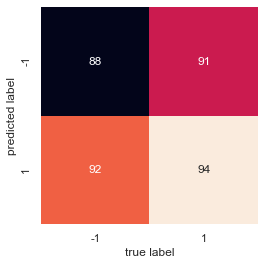

In [57]:
#使用测试数据做预测
y_pred = clf.predict(X[1500:])
# 画出confusion_matrix
plot_confusion_matrix(y_test=y[1500:], y_pred=y_pred)

## train and test random forest model

准备数据

In [58]:
X_columns = columns_baidu + columns_market + columns_sentiment
X,y = load_data_set(X_columns,Y_colum)

我们可以通过[GridSearchCV]**(https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)** 寻找合适的参数，寻找最优参数需要较高的运算（**方法：进行不同的组合**），这里我们人工尝试了一些参数，选择n_estimators=200, max_depth=5。

In [59]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=200, max_depth=5,random_state=0) 
## 参数：树的个数；树的深度；随机种子
# 输入数据X[:1500], y[:1500]
clf.fit(X[:1500], y[:1500].values.ravel())

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=0)

下面结果显示随机森林效果比决策树效果好，后续我们分析使用随机森林模型

accuracy_score:  0.5561643835616439


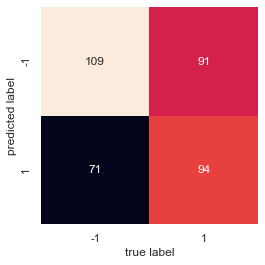

In [60]:
#使用测试数据做预测
y_pred = clf.predict(X[1500:])
# 画出confusion_matrix
plot_confusion_matrix(y_test=y[1500:], y_pred=y_pred)

## comprare the model's AUC with different training dataset

### AUC
这里我们再介绍一种模型度量指标AUC（Area Under Curve）被定义为ROC曲线下与坐标轴围成的面积，这种指标在非平衡样本中（例如正样本比例很小）是优秀的度量指标。在弄清楚AUC，我们要了解什么是ROC曲线,参考[An introduction to ROC analysis](https://ccrma.stanford.edu/workshops/mir2009/references/ROCintro.pdf)，这里介绍两个概念**True postive rate**和**False positive rate**（两个指标相互权衡、制约）。

Recall 也称为 True postive rate。$$TP\_rate = \frac {Positives\ correctly\ classified}{Total\ positives}$$
False positive rate 也称为 False alarm rate。 $$FP\_rate = \frac {Negatives\ incorrectly\ classified}{Total\ negatives}$$

ROC图是二维图，其中，TP_rate绘制在Y轴上，FP_rate绘制在X轴上。**ROC图描述了收益(真阳性)和成本(假阳性)之间的相对权衡**。下图是5个分类器的ROC图。这里有一个权衡:召回率(**TPR**)越高，分类器产生的假阳性(**FPR**)就越多。ROC中的一个点代表一个分类器，每个分类器产生一个(FP_rate，TP_rate)对，对应于ROC空间中的一个点。

我们可以通过调整 **threshold**（例如**预测结果判断为正样本的阈值** 80%？50%？30%？）来生成不同的分类器。

在概率阈值的规定下，例如，0.6，准确率大于0.6的分为正例，准确率小于等于0.6的分为负例。

**这里$(0,0)$和$(1,1)$点代表什么意思呢？(0,0)点表示阈值非常高，所有的正样本都没检测出来。(1,1)表示阈值非常低，所有的正样本都检测出来，但是所有的负样本也检查错误了**。（**最好分布在左上方**）

<img src="../img/ROC.png" align='left' height="300" width="300"/>

ROC曲线**对角线y = x表示随机猜测的策略**。

例如，如果一个分类器，在一半的时间里随机猜测是正类，它可以正确猜中正例和负例中的一半（50%概率判断为正样本），这将在ROC空间中产生点(0.5,0.5)。

如果90%的时间猜测正类别，则可以猜中90%的正例，但是假阳性率也会增加到90%(把90%的负例也猜成正例了），在ROC空间中产生(0.9,0.9)。

**好的分类器会尽可能地远离对角线(一般是朝向左上角)。比较分类器的一种方法是测量曲线下的面积(AUC)。一个完美的分类器的AUC等于1**。

<img src="../img/AUC.png" align='left' height="300" width="300"/>

In [61]:
def plot_roc_curve(fpr,tpr,label = None):
    """
    plot the roc curve
    """
    plt.plot(fpr,tpr,linewidth=2,label = label)
    plt.plot([0,1],[0,1],"k--")

### AUC with stock market data

In [62]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

clf = RandomForestClassifier(n_estimators=200, max_depth=5,random_state=0)
X_columns = columns_market
X,y = load_data_set(X_columns,Y_colum)

# 输入数据X[:1500], y[:1500]
clf.fit(X[:1500], y[:1500].values.ravel())

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=0)

AUC: 0.5094294294294294


array([0.58350804, 0.58421378, 0.51845285, 0.57372569, 0.4892563 ,
       0.57674129, 0.50121252, 0.51122751, 0.5442938 , 0.52587173,
       0.50283997, 0.56945374, 0.5068994 , 0.57175658, 0.56603669,
       0.53869747, 0.51367574, 0.49669462, 0.51962524, 0.57322679,
       0.51390826, 0.56795554, 0.52436089, 0.57927201, 0.56840644,
       0.45739249, 0.49577551, 0.56450701, 0.54322005, 0.56982007,
       0.51021968, 0.57539294, 0.57214781, 0.48640397, 0.56026886,
       0.56829371, 0.55401678, 0.49927141, 0.4849474 , 0.55899183,
       0.48499629, 0.426354  , 0.47450967, 0.52345576, 0.51204432,
       0.48255929, 0.54158208, 0.47703984, 0.47898447, 0.57548109,
       0.42961125, 0.46544504, 0.49827067, 0.56084926, 0.57014598,
       0.47502638, 0.50440215, 0.4901495 , 0.52144464, 0.51806887,
       0.55640425, 0.50600197, 0.57248836, 0.56942062, 0.5700712 ,
       0.56437536, 0.58244364, 0.56451384, 0.51377473, 0.51637951,
       0.56860651, 0.56629179, 0.48277828, 0.51964694, 0.46782

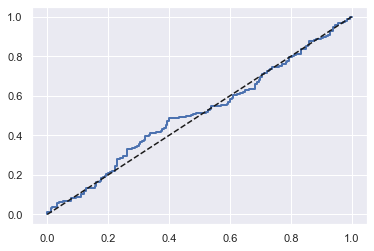

In [63]:
#使用测试数据做预测

y_pred = clf.predict(X[1500:])
y_scores = clf.predict_proba(X[1500:]) # 预测上涨和下跌的概率

y_scores = y_scores[:,1] # 选择出，属于正例（1）的概率

fpr_trade, tpr_trade, thresholds = roc_curve(y[1500:], y_scores)

print("AUC:",roc_auc_score(y[1500:], y_scores))

plot_roc_curve(fpr_trade,tpr_trade)

y_scores

### AUC with market data and Baidu index

AUC:  0.4763063063063063


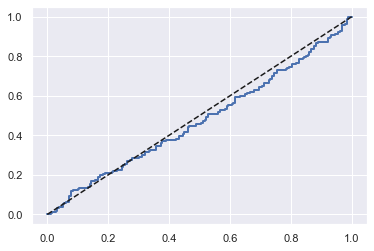

In [64]:
X_columns = columns_baidu + columns_market
X,y = load_data_set(X_columns,Y_colum)
# 输入数据X[:1500], y[:1500]
clf.fit(X[:1500], y[:1500].values.ravel())
#使用测试数据做预测
y_pred = clf.predict(X[1500:])

y_scores = clf.predict_proba(X[1500:]) # 预测上涨和下跌的概率
y_scores = y_scores[:,1] # 属于正例（1）的概率
fpr_trade_baidu, tpr_trade_baidu, thresholds = roc_curve(y[1500:], y_scores)
print("AUC: ",roc_auc_score(y[1500:], y_scores))
plot_roc_curve(fpr_trade_baidu,tpr_trade_baidu)
# print("AUC: ",roc_auc_score(y[1500:], abs(y_scores-1))) ###策略可以反过来~

### AUC with market, online review sentiments and Baidu index

AUC:  0.5764564564564565


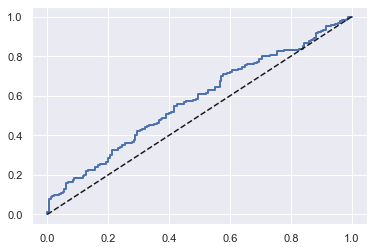

In [65]:
X_columns = columns_baidu + columns_market + columns_sentiment
X,y = load_data_set(X_columns,Y_colum)
# 输入数据X[:1500], y[:1500]
clf.fit(X[:1500], y[:1500].values.ravel())
#使用测试数据做预测
y_pred = clf.predict(X[1500:])

y_scores = clf.predict_proba(X[1500:]) # 预测上涨和下跌的概率 ##阈值设置
y_scores = y_scores[:,1] # 属于正例（1）的概率
fpr_full, tpr_full, thresholds = roc_curve(y[1500:], y_scores)
print("AUC: ",roc_auc_score(y[1500:], y_scores))
plot_roc_curve(fpr_full,tpr_full)

### comprare the model's AUC with different training dataset

Text(0, 0.5, 'True positive rate')

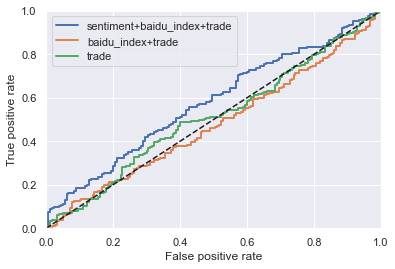

In [66]:
plt.plot(fpr_full,tpr_full,linewidth = 2, label = "sentiment+baidu_index+trade")
plt.plot(fpr_trade_baidu,tpr_trade_baidu,linewidth = 2, label = "baidu_index+trade")
plt.plot(fpr_trade,tpr_trade,linewidth = 2, label = "trade")
plt.plot([0,1],[0,1],"k--")
plt.axis([0,1,0,1])
plt.legend()
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")

思考：<font color=red face=雅黑>请使用随机森林模型预测第三天、第五天的涨跌，看看效果如何。y 可以取如下值：'up_down-2','up_down-4'，即Y_colum = ['up_down-2'] </font>

**Thanks a lot for your attention!**